In [1]:
import sys
sys.path.insert(1, '..')

import os, pickle

from physics.simulation import mcfm, msq, sample
from physics.analysis import zpair, zz4l
from datasets import jointlikelihood
from models import alice

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm
import hist

import torch
from torch.utils.data import TensorDataset
from lightning import Trainer

In [2]:
OUTPUT_DIR = '../jobs/alice/refactor-four-SBI-vs-BKG'
SCALER_FILE = 'scaler.pkl'
CHECKPOINT_DIR = 'checkpoints'
SAMPLE_DIR = '../..'

CHECKPOINT = 'checkpoint-alice-epoch=63-val_loss=0.69.ckpt'

VERSION = 0
LIGHTNING_DIR = f'lightning_logs/version_{VERSION}'

COMPONENT_NUMERATOR = msq.Component.SBI
COMPONENT_DENOMINATOR = msq.Component.BKG
COMPONENT_FILE = msq.Component.BKG

SAMPLE_SIZE = 100000
BATCH_SIZE = 1024
SEED = 42

In [3]:
xs = {
    msq.Component.SBI : 1.5569109,
    msq.Component.SIG : 0.15105108,
    msq.Component.INT : -0.22043824,
    msq.Component.BKG : 1.6270497
}

filenames = {
    msq.Component.SBI : 'ggZZ2e2m_sbi.csv',
    msq.Component.SIG : 'ggZZ2e2m_sig.csv',
    msq.Component.INT : 'ggZZ2e2m_int.csv',
    msq.Component.BKG : 'ggZZ2e2m_bkg.csv'
}

cmp_names = {
    msq.Component.SBI : 'SBI',
    msq.Component.SIG : 'SIG',
    msq.Component.INT : 'INT',
    msq.Component.BKG : 'BKG'
}

In [4]:
events = mcfm.from_csv(cross_section=xs[COMPONENT_FILE], file_path=os.path.join(SAMPLE_DIR, filenames[COMPONENT_FILE]), n_rows=int(SAMPLE_SIZE*1.2)).reweight(COMPONENT_FILE, COMPONENT_DENOMINATOR)

bkg_null = msq.MSQFilter('msq_bkg_sm', 0.0)

z_cand = zpair.ZPairCandidate(algorithm='leastsquare')
z_masses = zpair.ZPairMassWindow(z1=(70,115), z2=(70,115))
angles = zz4l.AngularVariables()
four_lepton_vars = zz4l.FourLeptonSystem()

events_processed = events.filter(bkg_null).calculate(z_cand).filter(z_masses).calculate(angles).calculate(four_lepton_vars)[:SAMPLE_SIZE]

features = ['cth_star', 'cth_1', 'cth_2', 'phi_1', 'phi', 'Z1_mass', 'Z2_mass', '4l_mass', '4l_rapidity']

X = events_processed.kinematics[features].to_numpy()

with open(os.path.join(OUTPUT_DIR, SCALER_FILE), 'rb') as f:
    scaler = pickle.load(f)

X_scaled = scaler.transform(X)

0.673827949576293
Weights > 0.0: 1.6270497000000002
Weights > 0.0: 1.6270497000000002
Weights > 0.0: 1.6270496999999997
Weights > 0.0: 1.6270496999999997
Weights > 0.0: 1.5788426394811728
Weights > 0.0: 1.5788426394811728
Weights > 0.0: 1.5788426394811728
Weights > 0.0: 1.3516853532215962


In [5]:
model_alice = alice.ALICE.load_from_checkpoint(os.path.join(OUTPUT_DIR, CHECKPOINT_DIR, CHECKPOINT))

/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/torch/cuda/__init__.py:628: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/torch/cuda/__init__.py:758: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() if nvml_count < 0 else nvml_count


In [6]:
predictions = model_alice(torch.tensor(X_scaled, dtype=torch.float32)).detach().view(-1).numpy()
ratio_predicted = predictions/(1-predictions)

In [7]:
NUMERATOR_weights_predicted = events_processed.weights.to_numpy() * ratio_predicted
NUMERATOR_weights_reweight = events_processed.weights.to_numpy() * (events_processed.reweight(COMPONENT_DENOMINATOR, COMPONENT_NUMERATOR).probabilities.to_numpy()/events_processed.probabilities.to_numpy())

Weights > 0.0: 1.2923479710136188


/tmp/ipykernel_230592/2562761081.py:60: RuntimeWarning: invalid value encountered in divide
  ax2.errorbar(hist_bkg.axes[0].centers, hist_bkg.values()/hist_bkg.values(), yerr=np.sqrt(hist_bkg.variances())/hist_bkg.values(), color='black', linestyle='--', drawstyle='steps-mid', label=f'{cmp_names[COMPONENT_DENOMINATOR]}', alpha=0.8)
/tmp/ipykernel_230592/2562761081.py:61: RuntimeWarning: invalid value encountered in divide
  ax2.errorbar(hist_pred.axes[0].centers, hist_pred.values()/hist_bkg.values(), yerr=np.sqrt((np.sqrt(hist_pred.variances())/hist_bkg.values())**2 + (-np.sqrt(hist_bkg.variances())*hist_pred.values()/hist_bkg.values()**2)**2), color='r', drawstyle='steps-mid', label=f'{cmp_names[COMPONENT_DENOMINATOR]} -> {cmp_names[COMPONENT_NUMERATOR]} (NN prediction)')
/tmp/ipykernel_230592/2562761081.py:62: RuntimeWarning: invalid value encountered in divide
  ax2.errorbar(hist_rew.axes[0].centers, hist_rew.values()/hist_bkg.values(), yerr=np.sqrt((np.sqrt(hist_rew.variances())/hi

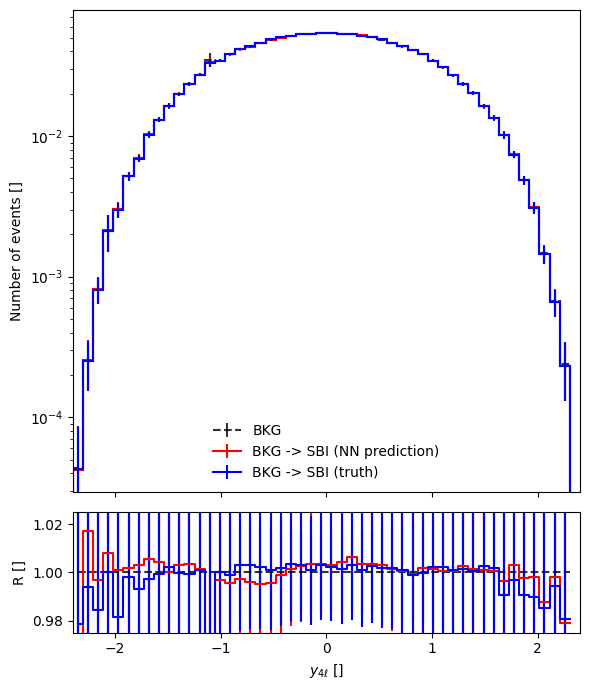

In [34]:
index = 8

kin_var = X[:,index]
label = ['$\mathrm{cos}(\\theta^*)$ []',
         '$\mathrm{cos}(\\theta_1)$ []',
         '$\mathrm{cos}(\\theta_2)$ []',
         '$\phi$ []',
         '$\phi_1$ []',
         '$m_{Z1}$ [GeV]',
         '$m_{Z2}$ [GeV]',
         '$m_{4\ell}$ [GeV]',
         '$y_{4\ell}$ []'][index]
bounds = [[-1,1],
          [-1,1],
          [-1,1],
          [-np.pi,np.pi],
          [-np.pi,np.pi],
          [70,115],
          [70,115],
          [160,1000],
          [-2.4,2.4]][index]

ybounds = [[0.98,1.02],
           [0.98,1.04],
           [0.98,1.04],
           [0.985,1.015],
           [0.985,1.015],
           [0.98,1.05],
           [0.98,1.05],
           [0.55,1.15],
           [0.975,1.025]][index]

BINS=50

hist_bkg = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
hist_bkg.fill(kin_var, weight=events_processed.weights)

hist_pred = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
hist_pred.fill(kin_var, weight=NUMERATOR_weights_predicted/np.sum(NUMERATOR_weights_predicted)*np.sum(NUMERATOR_weights_reweight))

hist_rew = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
hist_rew.fill(kin_var, weight=NUMERATOR_weights_reweight)

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

hist_bkg.plot(ax=ax1, color='black', linestyle='--', label=f'{cmp_names[COMPONENT_DENOMINATOR]}', alpha=0.8, yerr=np.sqrt(hist_bkg.variances()))
hist_pred.plot(ax=ax1, color='r', label=f'{cmp_names[COMPONENT_DENOMINATOR]} -> {cmp_names[COMPONENT_NUMERATOR]} (NN prediction)', yerr=np.sqrt(hist_pred.variances()))
hist_rew.plot(ax=ax1, color='b', label=f'{cmp_names[COMPONENT_DENOMINATOR]} -> {cmp_names[COMPONENT_NUMERATOR]} (truth)', yerr=np.sqrt(hist_rew.variances()))

ax1.set_ylabel('Number of events []')
ax1.set_yscale('log')
#ax1.set_ylim(0,10)
ax1.set_xlabel('')
ax1.set_xlim(*bounds)

ax1.legend(frameon=False)

ax2.errorbar(hist_bkg.axes[0].centers, hist_bkg.values()/hist_bkg.values(), yerr=np.sqrt(hist_bkg.variances())/hist_bkg.values(), color='black', linestyle='--', drawstyle='steps-mid', label=f'{cmp_names[COMPONENT_DENOMINATOR]}', alpha=0.8)
ax2.errorbar(hist_pred.axes[0].centers, hist_pred.values()/hist_bkg.values(), yerr=np.sqrt((np.sqrt(hist_pred.variances())/hist_bkg.values())**2 + (-np.sqrt(hist_bkg.variances())*hist_pred.values()/hist_bkg.values()**2)**2), color='r', drawstyle='steps-mid', label=f'{cmp_names[COMPONENT_DENOMINATOR]} -> {cmp_names[COMPONENT_NUMERATOR]} (NN prediction)')
ax2.errorbar(hist_rew.axes[0].centers, hist_rew.values()/hist_bkg.values(), yerr=np.sqrt((np.sqrt(hist_rew.variances())/hist_bkg.values())**2 + (-np.sqrt(hist_bkg.variances())*hist_rew.values()/hist_bkg.values()**2)**2), color='b', drawstyle='steps-mid', label=f'{cmp_names[COMPONENT_DENOMINATOR]} -> {cmp_names[COMPONENT_NUMERATOR]} (truth)')
         
ax2.set_xlabel(label)
ax2.set_ylabel('R []')
#ax2.set_yscale('log')
ax2.set_ybound(*ybounds)
ax2.set_xlim(*bounds)
fig.tight_layout()

plt.show()